In [4]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("dataset/dataset/dataset_step2_cleaned.csv", sep="|")

# pastikan Tahun numeric (ini penting banget)
df["Tahun"] = pd.to_numeric(df["Tahun"], errors="coerce")

# filter 2023–2026
df_filtered = df[df["Tahun"].between(2023, 2026)]

print("Total data awal:", len(df))
print("Total data filtered:", len(df_filtered))

print("\nSample data:")
print(df_filtered.head())

print("\nUnique years:")
print(df_filtered["Tahun"].unique())

Total data awal: 5264
Total data filtered: 3496

Sample data:
     DocID                                           Paragraf   Tahun  \
0    15001  Penelitian variasi bahasa pada lanskap linguis...  2024.0   
2    15003  Sambungan dalam dunia industri digunakan untuk...  2023.0   
3    15004  Sumber Energi Terbarukan (EBT) harus lah dapat...  2024.0   
4    15005  Pakan ternak dibutuhkan oleh semua jenis hewan...  2024.0   
437  15479  Beban listrik merupakan kebutuhan energi listr...  2024.0   

                                                 Judul  \
0    SKRIPSI VARIASI BAHASA PADA LANSKAP DI SEKITAR...   
2    SKRIPSI KARAKTERISTIK KEKUATAN MEKANIK SAMBUNG...   
3    SKRIPSI KAJI EKSPERIMENTAL PENGARUH VARIASI SU...   
4    SKRIPSI RANCANG BANGUN MESIN PRESS OTOMATIS KO...   
437  SKRIPSI PERAMALAN BEBAN LISTRIK KABUPATEN CILACAP   

                        Penulis  \
0    PRASASTI LISHERNANDA PUTRI   
2          AZAM AKMAL NUR IRSAN   
3           ZANUAR AHMAD HASANI   
4         

In [6]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text)  # hapus whitespace berlebih
    text = text.strip()
    return text

df["Paragraf_clean"] = df["Paragraf"].apply(clean_text)

In [7]:
def split_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    return sentences

df["Sentences"] = df["Paragraf_clean"].apply(split_sentences)
df["Sentence_Count_check"] = df["Sentences"].apply(len)

In [8]:
def word_count(text):
    return len(text.split())

df["Word_Count_check"] = df["Paragraf_clean"].apply(word_count)

df["WPS"] = df["Word_Count_check"] / df["Sentence_Count"].replace(0, np.nan)

In [9]:
noise_cols = [
    "Removed_Header",
    "Removed_Keyword",
    "Removed_Metadata",
    "Removed_Fuzzy",
    "Removed_Garbage"
]

# pastikan numeric
for col in noise_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["Noise_Score"] = df[noise_cols].sum(axis=1) / df["Word_Count_check"].replace(0, np.nan)

df["BR_Count"] = pd.to_numeric(df["BR_Count"], errors="coerce").fillna(0)

df["BR_ratio"] = df["BR_Count"] / df["Word_Count_check"].replace(0, np.nan)

In [10]:
df[["Word_Count_check", "Sentence_Count", "WPS", "Noise_Score", "BR_ratio"]].describe()

,Word_Count_check,Sentence_Count,WPS,Noise_Score,BR_ratio
count,5264.000000,5264.000000,5264.000000,5264.000000,5264.000000
mean,217.450418,10.898366,21.650676,0.005571,0.034498
std,89.914492,5.965934,7.411157,0.007406,0.032532
min,22.000000,1.000000,6.666667,0.000000,0.001538
25%,164.000000,8.000000,17.600000,0.000000,0.014851
50%,202.000000,10.000000,20.461538,0.004566,0.021978
75%,249.000000,12.000000,24.000000,0.007042,0.038961
max,968.000000,71.000000,165.000000,0.090909,0.368421


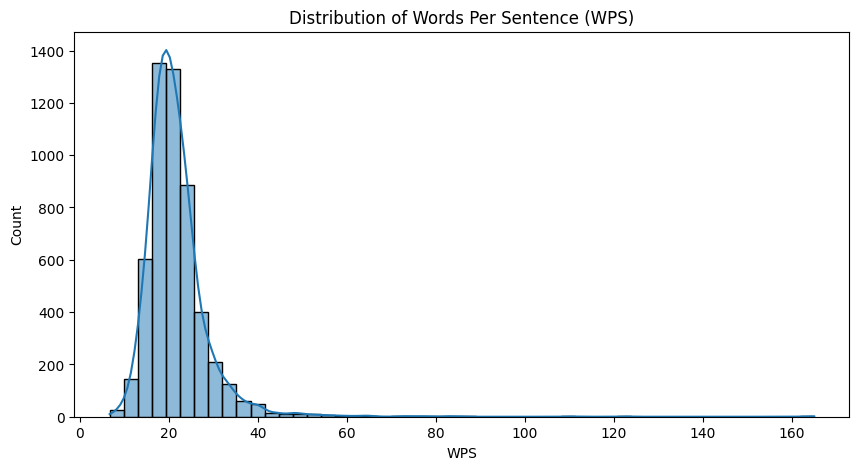

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df["WPS"], bins=50, kde=True)
plt.title("Distribution of Words Per Sentence (WPS)")
plt.show()

In [22]:
df[df["WPS"] > 80][["DocID","Tahun", "Paragraf", "WPS"]].head(3)

,DocID,Tahun,Paragraf,WPS
1097,16453,2024.0,Tenaga alih daya merupakan pekerja alih daya y...,83.5
1722,17483,2002.0,Sebagaimana yang telah diumanarikan dalen Gart...,165.0
1731,17492,1987.0,Tujuan perusahaan terutama perusahaan komersia...,163.0


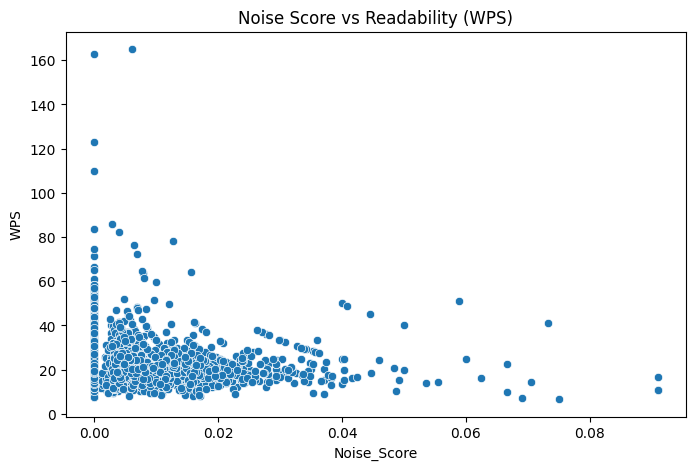

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Noise_Score", y="WPS")
plt.title("Noise Score vs Readability (WPS)")
plt.show()

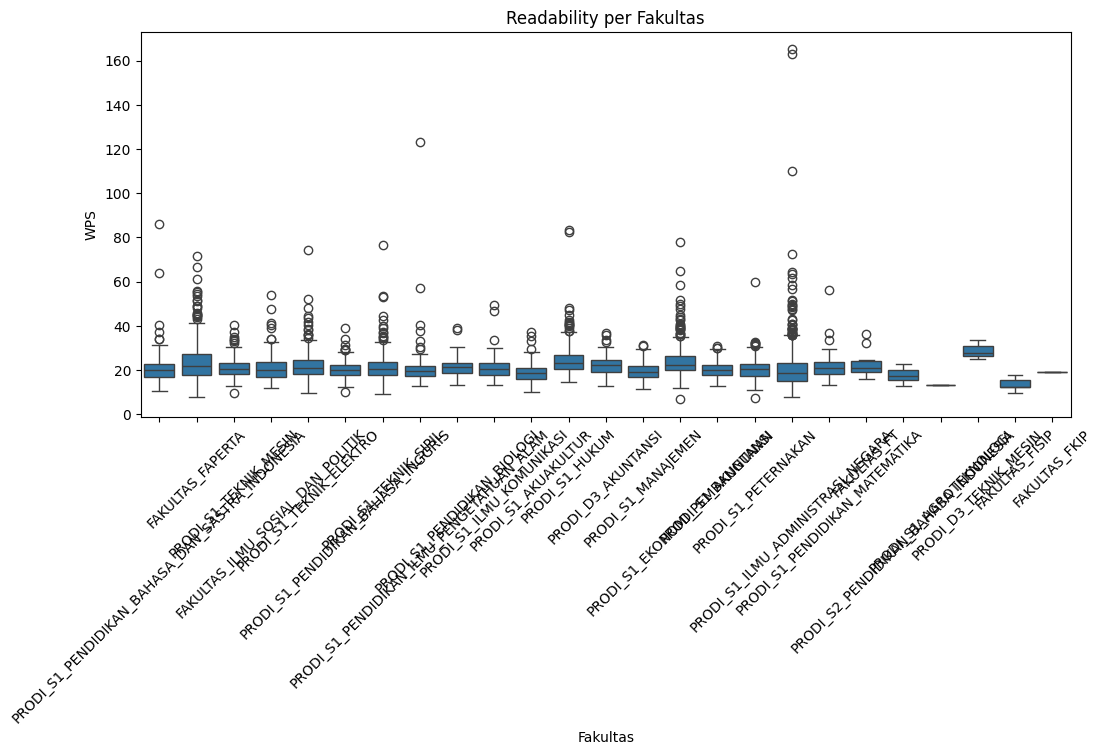

In [13]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="Fakultas", y="WPS")
plt.xticks(rotation=45)
plt.title("Readability per Fakultas")
plt.show()

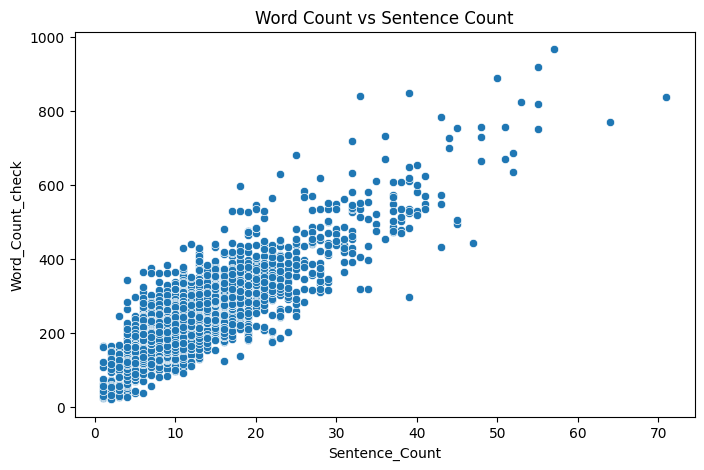

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sentence_Count", y="Word_Count_check")
plt.title("Word Count vs Sentence Count")
plt.show()

In [15]:
bad = df[
    (df["WPS"] > 40) |
    (df["Noise_Score"] > 0.3) |
    (df["Sentence_Count"] <= 1)
]

print("Jumlah data bermasalah:", len(bad))
bad.head()

Jumlah data bermasalah: 103


,DocID,Paragraf,Tahun,Judul,Penulis,Fakultas,Prodi,Keyword_Text,Has_Keyword,Removed_Header,...,BR_Count,Word_Count,Sentence_Count,Paragraf_clean,Sentences,Sentence_Count_check,Word_Count_check,WPS,Noise_Score,BR_ratio
15,15017,The experiment was to aim to know the effect o...,1992.0,SKRIPSI PENGARUH WAKTU PEMUPUKAN DAN DOSIS NPK...,SRI WULANSIH,FAKULTAS_FAPERTA,PRODI_S1_AGROTEKNOLOGI,NaN,False,0,...,5,266,4,The experiment was to aim to know the effect o...,[The experiment was to aim to know the effect ...,5,266,66.500000,0.0,0.018797
18,15020,The research of influence fungisida perpose to...,1992.0,SKRIPSI PENGARUH MACAM-MACAM FUNGISIDA TERHADA...,SUS AGUS SUTIRTO,FAKULTAS_FAPERTA,PRODI_S1_AGROTEKNOLOGI,NaN,False,0,...,12,221,4,The research of influence fungisida perpose to...,[The research of influence fungisida perpose t...,6,221,55.250000,0.0,0.054299
56,15062,The experiment entitled Domenge Gost Fertilize...,1993.0,SKRIPSI DOSIS PUPUK KANDANG KAMBING DAN EFEKTI...,WIDAYATI,FAKULTAS_FAPERTA,PRODI_S1_AGROTEKNOLOGI,NaN,False,0,...,17,283,7,The experiment entitled Domenge Gost Fertilize...,[The experiment entitled Domenge Gost Fertiliz...,9,283,40.428571,0.0,0.060071
89,15098,An experiment about the effect of kind growth ...,1991.0,SKRIPSI PENGARUH MACAM ZAT PENGATUR TUMBUH DAN...,YUN HENDRIYANTO,FAKULTAS_FAPERTA,PRODI_S1_AGROTEKNOLOGI,NaN,False,0,...,5,214,4,An experiment about the effect of kind growth ...,[An experiment about the effect of kind growth...,5,214,53.500000,0.0,0.023364
168,15185,The experiment of the effect time and range di...,1993.0,SKRIPSI PENGARUH MACAM MEDIA DAN JUMLAH MATA T...,RATNA IKA HANDOYO,FAKULTAS_FAPERTA,PRODI_S1_AGROTEKNOLOGI,NaN,False,0,...,16,242,6,The experiment of the effect time and range di...,[The experiment of the effect time and range d...,6,242,40.333333,0.0,0.066116


In [16]:
df["Quality_Score"] = (
    (1 / (1 + df["WPS"])) * 0.4 +
    (1 - df["Noise_Score"].fillna(0)) * 0.4 +
    (1 - df["BR_ratio"].fillna(0)) * 0.2
)

df["Quality_Score"].describe()

count    5264.000000
mean        0.609826
std         0.008481
min         0.533212
25%         0.606371
50%         0.611540
75%         0.615173
max         0.641248
Name: Quality_Score, dtype: float64

In [17]:
import pandas as pd
import numpy as np
import re
from collections import Counter

# =========================
# CLEAN TEXT
# =========================
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["Paragraf"].apply(clean_text)

# =========================
# BASIC FEATURES
# =========================
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

df["sentences"] = df["text"].apply(lambda x: [s.strip() for s in re.split(r"[.!?]+", x) if s.strip()])
df["sentence_count"] = df["sentences"].apply(len)

df["wps"] = df["word_count"] / df["sentence_count"].replace(0, np.nan)

# =========================
# NOISE SCORE
# =========================
noise_cols = ["Removed_Header","Removed_Keyword","Removed_Metadata","Removed_Fuzzy","Removed_Garbage"]

for c in noise_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    else:
        df[c] = 0

df["noise_score"] = df[noise_cols].sum(axis=1) / df["word_count"].replace(0, np.nan)

# =========================
# LEXICAL DIVERSITY
# =========================
df["lexical_diversity"] = df["text"].apply(
    lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
)

# =========================
# AVG WORD LENGTH
# =========================
df["avg_word_len"] = df["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)

# =========================
# SENTENCE VARIATION
# =========================
def sent_std(text):
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    lens = [len(s.split()) for s in sents]
    return np.std(lens) if len(lens) > 0 else 0

df["sent_std"] = df["text"].apply(sent_std)

# =========================
# ENTROPY
# =========================
def entropy(text):
    words = text.split()
    if len(words) == 0:
        return 0
    counts = Counter(words)
    probs = np.array(list(counts.values())) / len(words)
    return -np.sum(probs * np.log(probs))

df["entropy"] = df["text"].apply(entropy)

# =========================
# QUALITY SCORE v2
# =========================
df["quality_score"] = (
    df["lexical_diversity"] * 0.3 +
    (df["avg_word_len"] / df["avg_word_len"].max()) * 0.2 +
    (df["sent_std"] / df["sent_std"].max()) * 0.3 +
    (df["entropy"] / df["entropy"].max()) * 0.2
)

# =========================
# SUMMARY
# =========================
print("\n===== DATASET SUMMARY =====")
print(df[["word_count","sentence_count","wps","noise_score","lexical_diversity","sent_std","entropy","quality_score"]].describe())

print("\n===== QUALITY INSIGHT =====")
print("Mean Quality Score:", df["quality_score"].mean())
print("Std Quality Score :", df["quality_score"].std())
print("Min / Max:", df["quality_score"].min(), df["quality_score"].max())

# =========================
# OUTLIER CHECK
# =========================
bad = df[
    (df["wps"] > 40) |
    (df["noise_score"] > 0.3) |
    (df["sentence_count"] <= 1)
]

print("\n===== POTENTIAL BAD DATA =====")
print(len(bad), "rows flagged")


===== DATASET SUMMARY =====
        word_count  sentence_count          wps  noise_score  \
count  5264.000000     5264.000000  5264.000000  5264.000000   
mean    217.450418       11.588336    20.542278     0.005571   
std      89.914492        6.427291     7.020816     0.007406   
min      22.000000        1.000000     2.900000     0.000000   
25%     164.000000        8.000000    16.608333     0.000000   
50%     202.000000       10.000000    19.666667     0.004566   
75%     249.000000       13.000000    23.250000     0.007042   
max     968.000000       72.000000   165.000000     0.090909   

       lexical_diversity     sent_std      entropy  quality_score  
count        5264.000000  5264.000000  5264.000000    5264.000000  
mean            0.624418     9.743042     4.580204       0.447065  
std             0.093576     5.182105     0.271647       0.033932  
min             0.243759     0.000000     2.585959       0.312042  
25%             0.563153     6.593494     4.431154    

In [20]:
stanza.download("id")

2026-06-18 15:28:30 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-18 15:28:30 INFO: Downloading default packages for language: id (Indonesian) ...
2026-06-18 15:28:30 INFO: File exists: C:\Users\Danang ARA\stanza_resources\id\default.zip
2026-06-18 15:28:32 INFO: Finished downloading models and saved to C:\Users\Danang ARA\stanza_resources


In [ ]:
import stanza

nlp = stanza.Pipeline(
    "id",
    processors="tokenize,pos,depparse",
    use_gpu=True
)

2026-06-18 15:27:53 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-18 15:27:53 INFO: Downloading default packages for language: id (Indonesian) ...
2026-06-18 15:27:54 INFO: File exists: C:\Users\Danang ARA\stanza_resources\id\default.zip
2026-06-18 15:27:56 INFO: Finished downloading models and saved to C:\Users\Danang ARA\stanza_resources
2026-06-18 15:27:56 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-06-18 15:27:57 INFO: Downloaded file to C:\Users\Danang ARA\stanza_resources\resources.json
2026-06-18 15:27:57 WARNING: Language id package default expects mwt, which has been added
2026-06-18 15:27:57 INFO: Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |
| depparse  | gsd_charlm |

2026-06-18 15:27:57 INFO: Using device: cuda
2026-06-18 15:27:57 INFO: Loading: tokenize
2026-06-18 15:27:57 INFO: Loading: mwt
2026-06-18 15:27:57 INFO: Loading: pos
2026-06-18 15:27:59 INFO: Loading: depparse
2026-06-18 15:27:59 INFO: 



PipelineRequirementsException: 

---
Pipeline Requirements Error!
	Processor: DepparseProcessor
	Pipeline processors list: tokenize,mwt,pos,depparse
	Processor Requirements: {'lemma', 'tokenize', 'pos'}
		- fulfilled: {'tokenize', 'pos'}
		- missing: {'lemma'}

The processors list provided for this pipeline is invalid.  Please make sure all prerequisites are met for every processor.




In [ ]:
import pandas as pd
import numpy as np

def analyze_predicate(text):
    doc = nlp(text)

    verb_count = 0
    root_verbs = 0
    total_tokens = 0

    sentence_stats = []

    for sent in doc.sentences:
        sent_verbs = 0
        sent_root = None

        for word in sent.words:
            total_tokens += 1

            # VERB detection
            if word.upos == "VERB":
                verb_count += 1
                sent_verbs += 1

            # ROOT detection (predicate candidate)
            if word.deprel == "root":
                sent_root = word.upos
                if word.upos == "VERB":
                    root_verbs += 1

        sentence_stats.append(sent_verbs)

    return {
        "verb_count": verb_count,
        "sentence_count": len(doc.sentences),
        "root_is_verb_ratio": root_verbs / len(doc.sentences) if len(doc.sentences) > 0 else 0,
        "verb_density": verb_count / total_tokens if total_tokens > 0 else 0,
        "sentence_verb_std": np.std(sentence_stats) if len(sentence_stats) > 0 else 0
    }

In [ ]:
df_pred = df["Paragraf"].apply(analyze_predicate).apply(pd.Series)

df = pd.concat([df, df_pred], axis=1)

In [ ]:
df["PCS"] = (
    df["root_is_verb_ratio"] * 0.4 +
    df["verb_density"] * 0.3 +
    (1 / (1 + df["sentence_verb_std"])) * 0.3
)

In [ ]:
df["weak_predicate"] = (
    (df["root_is_verb_ratio"] < 0.5) &
    (df["verb_density"] < 0.05)
)

In [ ]:
print(df[[
    "verb_count",
    "verb_density",
    "root_is_verb_ratio",
    "sentence_verb_std",
    "PCS"
]].describe())

       verb_count   verb_count  verb_density  root_is_verb_ratio  \
count      5264.0  5264.000000   5264.000000         5264.000000   
mean          0.0    21.990881      0.091821            0.699893   
std           0.0    13.820952      0.043064            0.314778   
min           0.0     0.000000      0.000000            0.000000   
25%           0.0    15.000000      0.080348            0.636364   
50%           0.0    22.000000      0.101695            0.800000   
75%           0.0    29.000000      0.118577            0.900000   
max           0.0   132.000000      0.259434            1.000000   

       sentence_verb_std          PCS  
count        5264.000000  5264.000000  
mean            1.327015     0.457477  
std             0.850965     0.092578  
min             0.000000     0.091882  
25%             0.899347     0.402940  
50%             1.304780     0.472809  
75%             1.746987     0.526624  
max             8.104687     0.769767  


In [ ]:
df = df.loc[:, ~df.columns.duplicated()]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["PCS_norm"] = scaler.fit_transform(df[["PCS"]])

In [ ]:
from sklearn.cluster import KMeans

features = df[[
    "PCS_norm",
    "verb_density",
    "root_is_verb_ratio",
    "sentence_verb_std"
]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["predicate_cluster"] = kmeans.fit_predict(features)

In [ ]:
cluster_mean = df.groupby("predicate_cluster")["PCS"].mean().sort_values()

label_map = {
    cluster_mean.index[0]: "LOW_PREDICATE",
    cluster_mean.index[1]: "MEDIUM_PREDICATE",
    cluster_mean.index[2]: "HIGH_PREDICATE"
}

df["predicate_label"] = df["predicate_cluster"].map(label_map)

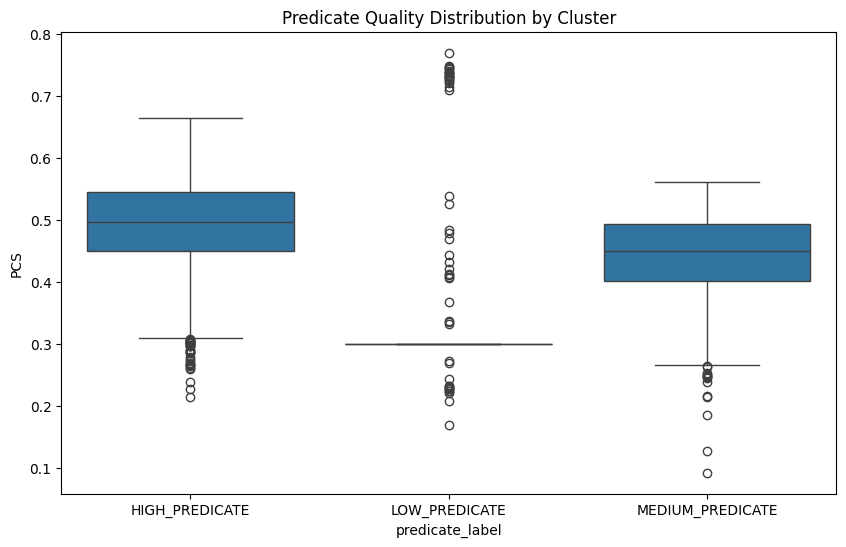

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="predicate_label", y="PCS")
plt.title("Predicate Quality Distribution by Cluster")
plt.show()

In [ ]:
NOMINAL_PATTERNS = [
    "analisis", "pengembangan", "implementasi", "penerapan",
    "perancangan", "pengujian", "evaluasi", "penelitian"
]

def nominal_score(text):
    text = text.lower()
    return sum([text.count(p) for p in NOMINAL_PATTERNS])

df["nominal_score"] = df["Paragraf"].apply(nominal_score)

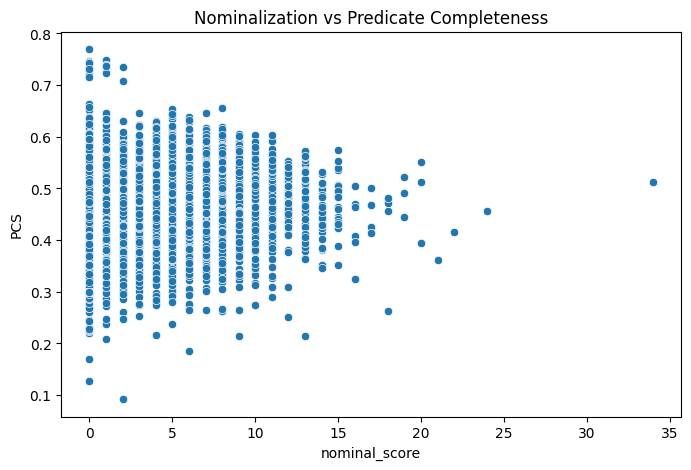

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="nominal_score", y="PCS")
plt.title("Nominalization vs Predicate Completeness")
plt.show()

In [ ]:
faculty_summary = df.groupby("Fakultas").agg({
    "PCS": "mean",
    "verb_density": "mean",
    "nominal_score": "mean"
}).sort_values("PCS")

faculty_summary

,PCS,verb_density,nominal_score
Fakultas,,,
PRODI_S1_PENDIDIKAN_BAHASA_INGGRIS,0.300855,0.001888,0.050000
FAKULTAS_FAPERTA,0.358233,0.030753,0.823270
FAKULTAS_FISIP,0.433303,0.099620,1.200000
PRODI_S1_PENDIDIKAN_MATEMATIKA,0.456173,0.117570,8.326667
PRODI_S1_ILMU_ADMINISTRASI_NEGARA,0.458401,0.103475,3.354916
FAKULTAS_ILMU_SOSIAL_DAN_POLITIK,0.460518,0.103443,6.000000
PRODI_S1_AGROTEKNOLOGI,0.469450,0.098113,0.000000
PRODI_S1_HUKUM,0.470707,0.107958,6.507042
PRODI_S2_PENDIDIKAN_BAHASA_INDONESIA,0.474389,0.112596,9.882353


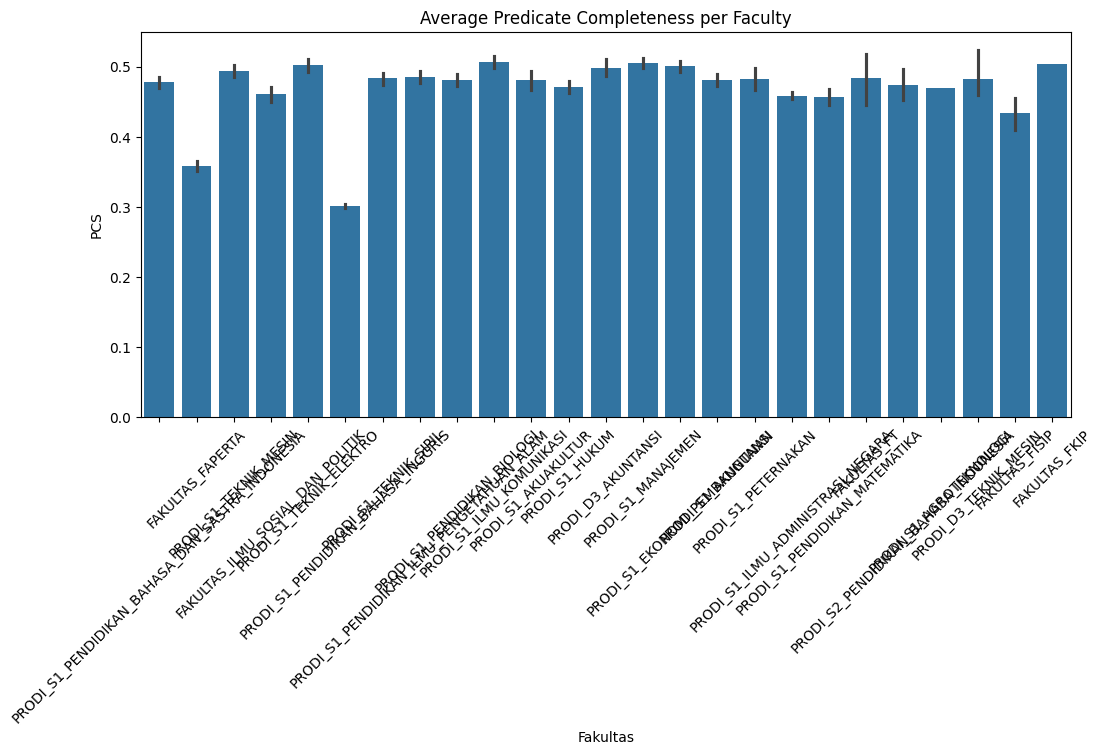

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="Fakultas", y="PCS", estimator="mean")
plt.xticks(rotation=45)
plt.title("Average Predicate Completeness per Faculty")
plt.show()

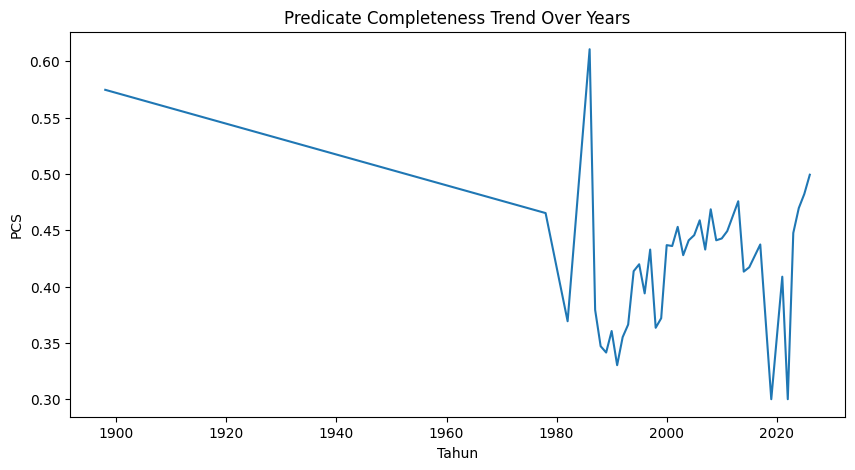

In [ ]:
if "Tahun" in df.columns:
    yearly = df.groupby("Tahun")["PCS"].mean().reset_index()

    plt.figure(figsize=(10,5))
    sns.lineplot(data=yearly, x="Tahun", y="PCS")
    plt.title("Predicate Completeness Trend Over Years")
    plt.show()

In [ ]:
outliers = df[
    (df["PCS"] < df["PCS"].quantile(0.1)) |
    (df["nominal_score"] > df["nominal_score"].quantile(0.9))
]

print("Weak writing samples:", len(outliers))

Weak writing samples: 499


In [ ]:
print("\n=== PREDICATE CLUSTER DISTRIBUTION ===")
print(df["predicate_label"].value_counts())

print("\n=== MEAN METRICS BY CLUSTER ===")
print(df.groupby("predicate_label")[["PCS","verb_density","nominal_score"]].mean())


=== PREDICATE CLUSTER DISTRIBUTION ===
predicate_label
HIGH_PREDICATE      3524
MEDIUM_PREDICATE     973
LOW_PREDICATE        767
Name: count, dtype: int64

=== MEAN METRICS BY CLUSTER ===
                       PCS  verb_density  nominal_score
predicate_label                                        
HIGH_PREDICATE    0.493261      0.103633       5.135074
LOW_PREDICATE     0.313195      0.004886       0.069100
MEDIUM_PREDICATE  0.441608      0.117571       5.220966


In [ ]:
from collections import Counter

verb_counter = Counter()

for text in df["Paragraf"]:
    doc = nlp(text)

    for sent in doc.sentences:
        for word in sent.words:
            if word.upos == "VERB":
                verb_counter[word.lemma.lower()] += 1

# top 20 predikat paling sering
top_verbs = verb_counter.most_common(20)

top_verbs

NameError: name 'df' is not defined

In [ ]:
import matplotlib.pyplot as plt

verbs, counts = zip(*top_verbs)

plt.figure(figsize=(10,5))
plt.bar(verbs, counts)
plt.xticks(rotation=45)
plt.title("Top Predikat (Verb Lemma) Mahasiswa")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

verbs, counts = zip(*top_verbs)

plt.figure(figsize=(10,5))
plt.bar(verbs, counts)
plt.xticks(rotation=45)
plt.title("Top Predikat (Verb Lemma) Mahasiswa")
plt.show()